# ASMC Method Tutorial

In this file we exemplify the workflow to use the `polynomial_sampler.py` module on a toy-model potential.

1. First we obtain a set of 1000 numerical minima to the potential $V(x) = (x_1^2 + x_2^2 -1)^2$, stored as a (1000, 2)-array. This vacuum-finding procedure was employed to sample the supergravity conformal manifold in the [manuscript](https://arxiv.org/abs/2511.02981).
2. Using `SparsePolynomialSampler`, the locus $x_1^2 + x_2^2 = 1$ is reconstructed

We also exemplify this workflow with the potential $V(x) = (x^3 + y^2 + x y z + z -1)^2$

In [38]:
# Importing packages
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import sympy

from ASMC import SparsePolynomialSampler, utils

from typing import Callable, Optional

### Vacuum-Finding Toolkit

In [39]:
def grad_norm_squared(
        V: Callable[[tf.Tensor], tf.Tensor],
        x: tf.Tensor,
        non_zero: Optional[list] = None,
        factor: float=1.0):
    """
    Compute the squared L2 norm of the gradient of V wrt x, 
    evaluated on x with only `non_zero` indices active.

    Parameters
    ----------
    V : callable
        Function mapping x to outputs (batch_size, 1).
    x : tf.Tensor
        Input tensor of shape (batch_size, n_vars).
    non_zero : list of int
        Indices of x to keep; others are zeroed. Takes all indices by default.
    factor : float, optional
        Scaling factor for the squared gradient norm.

    Returns
    -------
    tf.Tensor
        Scaled squared gradient norm of shape (batch_size,).
    """
    n_vars = x.shape[1]

    if non_zero is None or len(non_zero) == 0:
        non_zero = list(range(n_vars))

    mask = tf.constant([1.0 if i in non_zero else 0.0 for i in range(n_vars)], dtype=x.dtype)
    
    with tf.GradientTape() as tape:
        tape.watch(x)
        x_masked = x * mask  
        y = V(x_masked)

    gradients = tape.gradient(y, x)
    return factor * tf.reduce_sum(gradients**2, axis=1)

def vacuum_finder(
    V: Callable[[tf.Tensor], tf.Tensor],
    x: tf.Tensor,
    n_steps: int=2000,
    alpha: float=1e-3,
    tol: float = -10,
    resets: dict={},
    verbose: bool=False,
):
    """
    Minimizes ||∇V||^2 to find vacuum points.

    Parameters
    ----------
    V (callable)    : Potential function.
    x (tf.Variable) : Initial points. If None, random initialization is used.
    alpha (float)   : Learning rate.
    tol (float)     : Log Tolerance.
    resets (dict)   : Steps at which optimizer is reset, and rescaling of the alpha-parameter
    verbose (bool)  : Print progress.
    n_steps (int)   : Maximum number of iterations.

    Returns
    -------
    x (tf.Variable) : Final optimized points.
    history_loss (list) : Loss history_loss.
    history_rate (list) : Learning rate history_loss.
    """

    history_loss = []
    history_rate = []

    optimizer = tf.keras.optimizers.Adam(learning_rate=alpha)

    for step in range(n_steps):
        with tf.GradientTape() as tape:
            grad_norm_squared_this_step = grad_norm_squared(V, x)
            loss = tf.reduce_sum(grad_norm_squared_this_step)

        gradients = tape.gradient(loss, [x])

        # Reset optimizer if needed
        if step in resets.keys():    
            optimizer = tf.keras.optimizers.Adam(learning_rate=alpha/resets[step])

        optimizer.apply_gradients(zip(gradients, [x]))

        history_loss.append(loss.numpy())
        history_rate.append(optimizer.learning_rate.numpy())

        if verbose and step % 10 == 0:
            current_lr = optimizer.learning_rate.numpy()
            print(f"Step {step}:\t||∇V||^2 = {loss.numpy():.3g} with learning rate {current_lr:.2g}")

        # Convergence check
        if np.log(loss.numpy()) / np.log(10) <= tol:
            if verbose:
                print("\nConverged enough")
                print(f"Step {step}:\t||∇V||^2 = {loss.numpy():.3g}")
            break

    return history_loss, history_rate

## Higgs Potential

### Moduli Space Sampling -- Gradient Descent

In [12]:
# Definition of Potential
def V_Higgs(x):
    x1, x2 = tf.split(x, 2, axis=1)
    return (x1**2 + x2**2 -1)**2

# Randomly initialize the points
n_points = 1000
x_2d = tf.Variable(4*np.random.rand(n_points, 2)-2, dtype=tf.float32)

# Find vacua
n_steps = 2000
alpha = 1e-3

history_loss_2d, history_rate_2d = vacuum_finder(
    V=V_Higgs, 
    x=x_2d, 
    n_steps=n_steps, 
    alpha=alpha,
    verbose=True
)

Step 0:	||∇V||^2 = 3.89e+05 with learning rate 0.001
Step 10:	||∇V||^2 = 3.72e+05 with learning rate 0.001
Step 20:	||∇V||^2 = 3.56e+05 with learning rate 0.001
Step 30:	||∇V||^2 = 3.4e+05 with learning rate 0.001
Step 40:	||∇V||^2 = 3.26e+05 with learning rate 0.001
Step 50:	||∇V||^2 = 3.12e+05 with learning rate 0.001
Step 60:	||∇V||^2 = 2.98e+05 with learning rate 0.001
Step 70:	||∇V||^2 = 2.86e+05 with learning rate 0.001
Step 80:	||∇V||^2 = 2.74e+05 with learning rate 0.001
Step 90:	||∇V||^2 = 2.63e+05 with learning rate 0.001
Step 100:	||∇V||^2 = 2.52e+05 with learning rate 0.001
Step 110:	||∇V||^2 = 2.42e+05 with learning rate 0.001
Step 120:	||∇V||^2 = 2.33e+05 with learning rate 0.001
Step 130:	||∇V||^2 = 2.24e+05 with learning rate 0.001
Step 140:	||∇V||^2 = 2.15e+05 with learning rate 0.001
Step 150:	||∇V||^2 = 2.07e+05 with learning rate 0.001
Step 160:	||∇V||^2 = 1.99e+05 with learning rate 0.001
Step 170:	||∇V||^2 = 1.92e+05 with learning rate 0.001
Step 180:	||∇V||^2 = 1

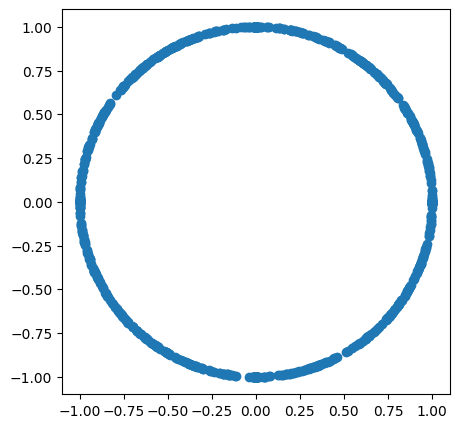

In [4]:
# Filtering trivial solution
data_higgs = x_2d.numpy()
mask = np.linalg.norm(data_higgs, axis=1) > 1e-3

data_higgs = data_higgs[mask]

plt.figure(figsize=(5,5))
plt.scatter(*data_higgs.T)
plt.show()

### Manifold Reconstruction

In [5]:
sampler_circle = SparsePolynomialSampler(
    data_x=data_higgs,
    max_degree=4,
    num_vars=2,
    max_num_monomials=3,
    prob_add= lambda i,n_iter: 0., 
    prob_remove= lambda i,n_iter: 0., 
    prob_modify= lambda i,n_iter: 0.5, 
    prob_multiply= lambda i,n_iter: 0.25, 
    prob_divide= lambda i,n_iter: 0.25, 
    regularisation_factor=1e3,
    sigma_proposal = lambda i,n_iter: 0.1,
    )

Pre-compute multiply/divide transitions...
  Average of multiply transitions: 1.33
  Average of divide transitions: 1.33
Number of possible terms in the polynomial: 15


In [6]:
# ASMC optimization
all_out = sampler_circle.run_annealing_is(
    n_iter=500,       
    n_particles=1000,  
    verbose=True,
)

Iteration 1/500, 	Beta: 4e-06, 	Acceptance rate: 0.96, 	ESS: 998.09/1000, 	Best loss: 225.522268,	Elapsed time: 0.74s, 	Prob (0.5, 0.25, 0.25, 0.0, 0.0), 	Best pol : 1.5844*x1*x2^3 + 0.8087*x1^2*x2^2 - 2.0991*x1^3*x2
Iteration 2/500, 	Beta: 6e-06, 	Acceptance rate: 0.95, 	ESS: 987.07/1000, 	Best loss: 225.522268,	Elapsed time: 0.75s, 	Prob (0.5, 0.25, 0.25, 0.0, 0.0), 	Best pol : 1.5844*x1*x2^3 + 0.8087*x1^2*x2^2 - 2.0396*x1^3*x2
Iteration 3/500, 	Beta: 9e-06, 	Acceptance rate: 0.96, 	ESS: 975.95/1000, 	Best loss: 225.522268,	Elapsed time: 0.76s, 	Prob (0.5, 0.25, 0.25, 0.0, 0.0), 	Best pol : 0.8087*x1^2*x2 + 1.5844*x1*x2^3 - 2.0396*x1^3*x2
Iteration 4/500, 	Beta: 1.4e-05, 	Acceptance rate: 0.95, 	ESS: 968.11/1000, 	Best loss: 225.522268,	Elapsed time: 0.77s, 	Prob (0.5, 0.25, 0.25, 0.0, 0.0), 	Best pol : -1.0781*x1*x2 + 2.0491*x1*x2^3 - 1.1464*x1^3*x2
Iteration 5/500, 	Beta: 2e-05, 	Acceptance rate: 0.96, 	ESS: 957.68/1000, 	Best loss: 225.522268,	Elapsed time: 0.78s, 	Prob (0.5, 0.25

In [ ]:
# Local search around best ASMC solution
best_coeffs = all_out[0]
bc_trunc = sampler_circle.apply_coefficient_threshold(best_coeffs)
res, loss = sampler_circle.local_search(best_coeffs,n_steps=1000,use_reg=False)

In [16]:
# Normalisation
sampler_circle.min_coeff_threshold = 1e-3
res_trunc = sampler_circle.apply_coefficient_threshold(res)
nonzero_indices = np.nonzero(res_trunc)
coeff_min = np.min(abs(res_trunc[nonzero_indices]))

# Final reconstruction
sympy.simplify(sampler_circle.polynomial_to_string(res/coeff_min, 1e-3))

x1**2*(-x1**2 - x2**2 + 1)

## Higher Order Potential

### Moduli Space Sampling -- Gradient Descent

In [46]:
# Definition of Potential
def V_3d(x):
    x1, x2, x3 = tf.split(x, 3, axis=1)
    return (x1**3 + x2**2 + x3 + x1*x2*x3 -1)**2

# Randomly initialize the points
n_points = 10_000
x_3d = tf.Variable(4*np.random.rand(n_points, 3)-2, dtype=tf.float32)

# Find vacua
n_steps = 3500
alpha = 1e-3

history_loss_3d, history_rate_3d = vacuum_finder(
    V=V_3d, 
    x=x_3d, 
    n_steps=n_steps, 
    alpha=alpha,
    verbose=True,
    resets={k:1 for k in [250,500,750,1000,1250,1500,1750,2000, 3000]}
)

Step 0:	||∇V||^2 = 5.99e+07 with learning rate 0.001
Step 10:	||∇V||^2 = 5.63e+07 with learning rate 0.001
Step 20:	||∇V||^2 = 5.29e+07 with learning rate 0.001
Step 30:	||∇V||^2 = 4.97e+07 with learning rate 0.001
Step 40:	||∇V||^2 = 4.68e+07 with learning rate 0.001
Step 50:	||∇V||^2 = 4.41e+07 with learning rate 0.001
Step 60:	||∇V||^2 = 4.16e+07 with learning rate 0.001
Step 70:	||∇V||^2 = 3.93e+07 with learning rate 0.001
Step 80:	||∇V||^2 = 3.71e+07 with learning rate 0.001
Step 90:	||∇V||^2 = 3.52e+07 with learning rate 0.001
Step 100:	||∇V||^2 = 3.33e+07 with learning rate 0.001
Step 110:	||∇V||^2 = 3.16e+07 with learning rate 0.001
Step 120:	||∇V||^2 = 3e+07 with learning rate 0.001
Step 130:	||∇V||^2 = 2.86e+07 with learning rate 0.001
Step 140:	||∇V||^2 = 2.72e+07 with learning rate 0.001
Step 150:	||∇V||^2 = 2.59e+07 with learning rate 0.001
Step 160:	||∇V||^2 = 2.47e+07 with learning rate 0.001
Step 170:	||∇V||^2 = 2.35e+07 with learning rate 0.001
Step 180:	||∇V||^2 = 2.2

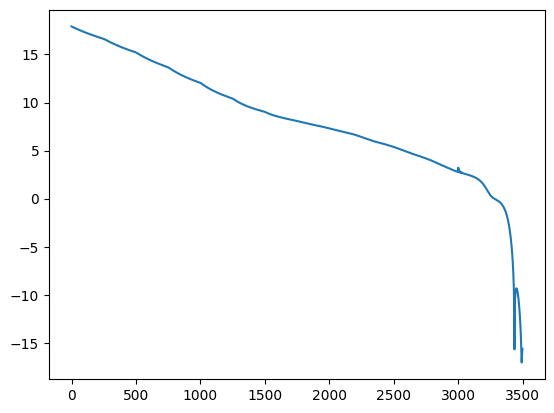

In [47]:
plt.plot(np.log(history_loss_3d))

In [48]:
x1 = x_3d.numpy()[:,0]
x2 = x_3d.numpy()[:,1]
x3 = x_3d.numpy()[:,2]

In [49]:
np.sum((x1**3 + x2**2 + x3 + x1*x2*x3 - 1)**2)

478.4418

In [50]:
print(np.sum(((x1**3 + x2**2 + x3 + x1*x2*x3 - 1)**2)<1e-1))
#some points have converged on another locus : remove them 
mask = ((x1**3 + x2**2 + x3 + x1*x2*x3 - 1)**2)<1e-4
x_3d_filtered = x_3d.numpy()[mask,:]
print(x_3d_filtered.shape)

9481
(9481, 3)


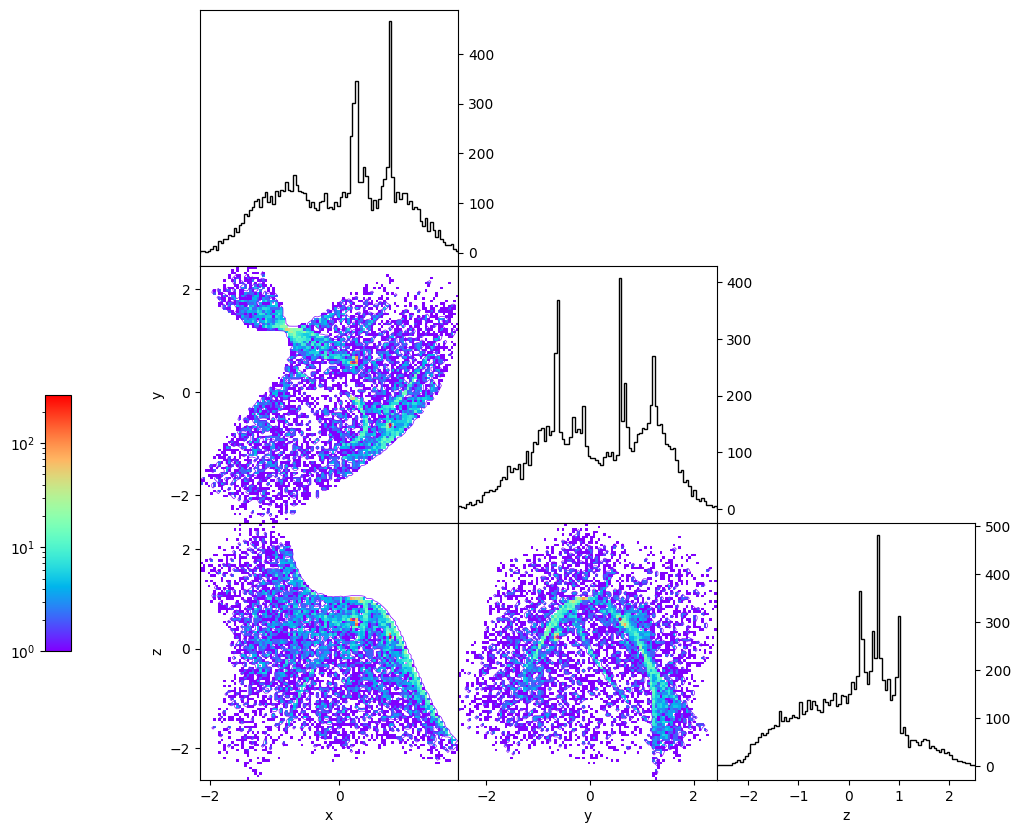

In [51]:
utils.triangular_plot(x_3d_filtered,names=['x','y','z'],figsize=(10,10))

### Manifold Reconstruction

In [52]:
sampler_3d = SparsePolynomialSampler(
    data_x=x_3d_filtered,
    max_degree=5,
    num_vars=3,
    max_num_monomials=6,
    prob_add= lambda i,n_iter: 0., 
    prob_remove= lambda i,n_iter: 0., 
    prob_modify= lambda i,n_iter: 0.1, 
    prob_multiply= lambda i,n_iter: 0.45, 
    prob_divide= lambda i,n_iter: 0.45, 
    regularisation_factor=1e3,
    sigma_proposal = lambda i,n_iter: 0.1,
    )

Pre-compute multiply/divide transitions...
  Average of multiply transitions: 1.88
  Average of divide transitions: 1.88
Number of possible terms in the polynomial: 56


In [53]:
# ASMC optimization
all_out = sampler_3d.run_annealing_is(
    n_iter=1000,       
    n_particles=1000,  
    verbose=True,
    adaptative_temp=True,
    degree_bias=0.,
    sparsity_factor=0.,
    adaptation_strength=lambda i,n_iter : 0.05,
    target_acc_rate = lambda x,y : 0.8 - 0.5 * x/y,
    beta_schedule=lambda i,n_iter: 1e-8
)


Iteration 1/1000, 	Beta: 1e-08, 	Acceptance rate: 1.00, 	ESS: 1000.00/1000, 	Best loss: 32864.184214,	Elapsed time: 0.18s, 	Prob (0.1, 0.45, 0.45, 0.0, 0.0), 	Best pol : 0.7833*x1*x2*x3 - 0.1918*x1^2*x3 - 0.9557*x1^2*x2 + 0.3404*x1*x3^3 + 0.0752*x1^3*x3^2
Iteration 2/1000, 	Beta: 1.1e-08, 	Acceptance rate: 1.00, 	ESS: 999.99/1000, 	Best loss: 18249.847185,	Elapsed time: 0.32s, 	Prob (0.1, 0.45, 0.45, 0.0, 0.0), 	Best pol : 0.0944*x3 - 0.9904*x2^2 + 0.4703*x1*x2 - 0.0045*x1*x2^2 + 0.7119*x2^2*x3^2 - 0.1387*x1^2*x2^2*x3
Iteration 3/1000, 	Beta: 1.1e-08, 	Acceptance rate: 1.00, 	ESS: 999.98/1000, 	Best loss: 18249.847185,	Elapsed time: 0.44s, 	Prob (0.1, 0.45, 0.45, 0.0, 0.0), 	Best pol : 0.0944*x3 - 0.9904*x2^2 + 0.4703*x1*x2 + 0.7119*x2*x3^2 - 0.0045*x1*x2^2 - 0.1387*x1^2*x2^2*x3
Iteration 4/1000, 	Beta: 1.2e-08, 	Acceptance rate: 1.00, 	ESS: 999.97/1000, 	Best loss: 18249.847185,	Elapsed time: 0.59s, 	Prob (0.1, 0.45, 0.45, 0.0, 0.0), 	Best pol : 0.0944*x3 - 0.9904*x2^2 + 0.4703*x1*x2 

In [56]:
best_coeffs = all_out[0]
bc_trunc = sampler_3d.apply_coefficient_threshold(best_coeffs)
res, loss = sampler_3d.local_search(best_coeffs,n_steps=10000,use_reg=False)

In [57]:
sampler_3d.polynomial_to_string(res)
sampler_3d.min_coeff_threshold = 1e-3
res_trunc = sampler_3d.apply_coefficient_threshold(res)
nonzero_indices = np.nonzero(res_trunc)
coeff_min = np.min(abs(res_trunc[nonzero_indices]))

print(sympy.simplify(sampler_3d.polynomial_to_string(res_trunc/coeff_min))) # Up to a factorisation this should work

2.2626*x1**4 + x1**2*x2*x3 - 4.9662*x1**2 + 1.6366


In [ ]:
1.0*x1**3 + 1.0*x1*x2*x3 + 1.0001*x2**2 + x3 - 1.0